# BÖLÜM 1: GİRİŞ VE VERİ YÜKLEME
## 1.1 Kütüphaneler

In [82]:
# Veri Manipülasyonu
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Ön İşleme ve Değerlendirme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Modeller
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Uyarıları Kapatma (Çıktıların temiz kalması için)
import warnings
warnings.filterwarnings('ignore')

# Temel Görselleştirme Ayarları
sns.set_theme(style="darkgrid")

## 1.2 Veri Seti Yükleme ve İnceleme

In [83]:
file_path_train = "train.csv"
file_path_test = "test.csv"

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

In [84]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [85]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [86]:
df_train.shape

(8693, 14)

In [87]:
df_test.shape

(4277, 13)

In [88]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


# BÖLÜM 2: ÖZELLİK MÜHENDİSLİĞİ (V1)
## 2.1 Temel Özellik Çıkarımı

In [89]:
for df in [df_train, df_test]:
    
    # PassengerID parçalama
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])

    # Gruptaki kişi sayısını hesaplama
    group_sizes = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_sizes)

    # Kabin parçalama
    df['Cabin'] = df['Cabin'].fillna('None/None/None')

    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['CabinNum'] = df['Cabin'].apply(lambda x: x.split('/')[1])
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2])

    # Parçalanmış Kabin sütununu kaldırma
    df.drop('Cabin', axis=1, inplace=True)

print("Parçalama işlemi tamamlandı.")

Parçalama işlemi tamamlandı.


In [90]:
df_train[['Group', 'GroupSize', 'Deck', 'CabinNum', 'Side']].head()

,Group,GroupSize,Deck,CabinNum,Side
0,0001,1,B,0,P
1,0002,1,F,0,S
2,0003,2,A,0,S
3,0003,2,A,0,S
4,0004,1,F,1,S


In [91]:
df_test[['Group', 'GroupSize', 'Deck', 'CabinNum', 'Side']].head()

,Group,GroupSize,Deck,CabinNum,Side
0,0013,1,G,3,S
1,0018,1,F,4,S
2,0019,1,C,0,S
3,0021,1,C,1,S
4,0023,1,F,5,S


## 2.2 Eksik Veri Analizi

In [92]:
missing_values_train = df_train.isnull().sum()
missing_values_train_percent = (missing_values_train / len(df_train)) * 100
missing_values_test = df_test.isnull().sum()
missing_values_test_percent = (missing_values_test / len(df_test)) * 100

In [93]:
print("Train Setindeki Eksik Değerler:")
print(missing_values_train) 
print("\nTrain Setindeki Eksik Değerlerin Yüzdesi:")
print(missing_values_train_percent)

Train Setindeki Eksik Değerler:
PassengerId       0
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Group             0
GroupSize         0
Deck              0
CabinNum          0
Side              0
dtype: int64

Train Setindeki Eksik Değerlerin Yüzdesi:
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
Group           0.000000
GroupSize       0.000000
Deck            0.000000
CabinNum        0.000000
Side            0.000000
dtype: float64


In [94]:
print("\nTest Setindeki Eksik Değerler:")
print(missing_values_test)
print("\nTest Setindeki Eksik Değerlerin Yüzdesi:")
print(missing_values_test_percent)


Test Setindeki Eksik Değerler:
PassengerId       0
HomePlanet       87
CryoSleep        93
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
Group             0
GroupSize         0
Deck              0
CabinNum          0
Side              0
dtype: int64

Test Setindeki Eksik Değerlerin Yüzdesi:
PassengerId     0.000000
HomePlanet      2.034136
CryoSleep       2.174421
Destination     2.151040
Age             2.127660
VIP             2.174421
RoomService     1.917232
FoodCourt       2.478373
ShoppingMall    2.291326
Spa             2.361468
VRDeck          1.870470
Name            2.197802
Group           0.000000
GroupSize       0.000000
Deck            0.000000
CabinNum        0.000000
Side            0.000000
dtype: float64


# BÖLÜM 3: EKSİK VERİ DOLDURMA (IMPUTATION)
## 3.1 Temel Veri Doldurma

In [95]:
# None yapılan kabinleri NaN yapma
for df in [df_train, df_test]:
    for col in ['Deck', 'CabinNum', 'Side']:
        df[col] = df[col].replace('None', np.nan)

# Harcama sütunlarının listesi 
spent_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Harcama ile CryoSleep ilişki kurma
for df in [df_train, df_test]:
    # CryoSleep durumundakilerin harcamalarını sıfır yapma
    for col in spent_cols:
        df.loc[df['CryoSleep'] == True, col] = df.loc[df['CryoSleep'] == True, col].fillna(0)

    # Harcaması sıfır olmayanların CryoSleep durumunu False yapma
    total_spent = df[spent_cols].sum(axis=1)
    df.loc[total_spent > 0, 'CryoSleep'] = df.loc[total_spent > 0, 'CryoSleep'].fillna(False)

print("Mantıklsallaştırma işlemi tamamlandı.")


Mantıklsallaştırma işlemi tamamlandı.


In [96]:
df_train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep        98
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
Group             0
GroupSize         0
Deck            199
CabinNum        199
Side            199
dtype: int64

In [97]:
df_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        38
Destination      92
Age              91
VIP              93
RoomService      57
FoodCourt        67
ShoppingMall     63
Spa              59
VRDeck           51
Name             94
Group             0
GroupSize         0
Deck            100
CabinNum        100
Side            100
dtype: int64

## 3.2 VIP ve CryoSleep Kuralları

In [98]:
# VIP durumunun gezegenlere göre dağılımı
print("--- VIP vs Gezegen Dağılımı ---")
print(pd.crosstab(df_train['HomePlanet'], df_train['VIP']))

# VIP durumunun güvertelere (Deck) göre dağılımı
print("\n--- VIP vs Güverte Dağılımı ---")
print(pd.crosstab(df_train['Deck'], df_train['VIP']))

--- VIP vs Gezegen Dağılımı ---
VIP         False  True 
HomePlanet              
Earth        4487      0
Europa       1958    131
Mars         1653     63

--- VIP vs Güverte Dağılımı ---
VIP   False  True 
Deck              
A       215     35
B       725     42
C       687     41
D       438     31
E       846     15
F      2695     29
G      2493      0
T         5      0


In [99]:
for df in [df_train, df_test]:
    # Dünyalı bir adam VIP olamaz
    df.loc[df['HomePlanet'] == 'Earth', 'VIP'] = df.loc[df['HomePlanet'] == 'Earth', 'VIP'].fillna(False)
    # G ve T güvertelerinde VIP olamaz
    df.loc[df['Deck'].isin(['G', 'T']), 'VIP'] = df.loc[df['Deck'].isin(['G', 'T']), 'VIP'].fillna(False)

    # VIP durumuna göre diğer sütunları doldurma
    group_cols = ['HomePlanet', 'Deck', 'Side', 'VIP']
    for col in ['CryoSleep', 'Destination']:
        df[col] = df.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

print("VIP mantık doldurma işlemi tamamlandı.")

VIP mantık doldurma işlemi tamamlandı.


In [100]:
print("Kalan Eksik Veriler (Train):")
print(df_train[['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'VIP']].isnull().sum())

Kalan Eksik Veriler (Train):
HomePlanet    201
CryoSleep      37
Deck          199
Side          199
VIP            87
dtype: int64


In [101]:
print("Kalan Eksik Veriler (Test):")
print(df_test[['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'VIP']].isnull().sum())

Kalan Eksik Veriler (Test):
HomePlanet     87
CryoSleep      15
Deck          100
Side          100
VIP            48
dtype: int64


## 3.3 Harcama Eksiklikleri

In [102]:
# Harcama sütunlarının listesi
spent_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for df in [df_train, df_test]:
    # Güverteye göre Gezegen doldurma
    # A, B, C ve T güvertelerinde bulunan yolcuların gezegenini Europa olarak doldurma
    df.loc[df['Deck'].isin(['A', 'B', 'C', 'T']), 'HomePlanet'] = df.loc[df['Deck'].isin(['A', 'B', 'C', 'T']), 'HomePlanet'].fillna('Europa')

    # (G -> Earth)
    df.loc[df['Deck'] == 'G', 'HomePlanet'] = df.loc[df['Deck'] == 'G', 'HomePlanet'].fillna('Earth')

    # Kalan HomePlanet eksiklerini en çok tekrar eden değerle (mode) doldur
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])

    # Kalan CryoSleep eksiklerini harcama durumuna göre doldur
    total_spent = df[spent_cols].sum(axis=1)
    df['CryoSleep'] = df['CryoSleep'].fillna(total_spent == 0)

    # Kalan Deck, Side ve VIP eksiklerini mod ile doldurma
    df['Deck'] = df['Deck'].fillna(df['Deck'].mode()[0])
    df['Side'] = df['Side'].fillna(df['Side'].mode()[0])
    df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

print("Kategorik ve mantıksal eksik verilerin tamamı temizlendi!")

Kategorik ve mantıksal eksik verilerin tamamı temizlendi!


In [103]:
print(df_train[['HomePlanet', 'CryoSleep', 'Deck', 'Side', 'VIP']].isnull().sum())

HomePlanet    0
CryoSleep     0
Deck          0
Side          0
VIP           0
dtype: int64


In [104]:
df_train.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Destination     103
Age             179
VIP               0
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
Group             0
GroupSize         0
Deck              0
CabinNum        199
Side              0
dtype: int64

## 3.4 Aile ve Grup İçi Doldurma

In [105]:
for df in [df_train, df_test]:
    df['Name'] = df['Name'].fillna('Unknown Unknown')

    # Soyadı çıkarma
    df['Surname'] = df['Name'].apply(lambda x: x.split()[-1])

    # Unknown soyadlarını NaN olarak değiştirme
    df['Surname'] = df['Surname'].replace('Unknown', np.nan)

# Soyada göre Aile bazlı doldurma 
for df in [df_train, df_test]:
    for col in ['HomePlanet', 'Destination']:
        # Önce soyada göre, eğer soyadında eksik varsa grup bazlı doldurma
        df[col] = df.groupby('Surname')[col].transform(lambda x: x.ffill().bfill())
        df[col] = df.groupby('Group')[col].transform(lambda x: x.ffill().bfill())

## 3.5 Aile İçi Harcama Dağılımı

In [106]:
for df in [df_train, df_test]:
    # Kişi bazlı harcamalar
    spent_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpent'] = df[spent_cols].sum(axis=1)

    # Aile bazlı harcamalar
    df['FamilySpent'] = df.groupby('Surname')['TotalSpent'].transform('sum')

    # Aile içi harcama oranı
    df['FamilySpentRatio'] = df['TotalSpent'] / (df['FamilySpent'] + 1)

print("Aile bazlı harcama özellikleri oluşturuldu!")

Aile bazlı harcama özellikleri oluşturuldu!


## 3.6 Genel Temizlik

In [107]:
# Harcama sütunları
spent_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for df in [df_train, df_test]:
    # Kalan Gezegen ve Rota eksiklerini en çok tekrar edenle (mode) doldur
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
    
    # Yaş eksiğini, kişinin geldiği gezegenin yaş medyanı ile doldur
    df['Age'] = df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
    
    # Kalan tüm harcama eksiklerini 0 yapalım (çünkü geminin çoğunluğu ekstra para harcamıyor)
    for col in spent_cols:
        df[col] = df[col].fillna(0)
        
    # Harcamalardaki NaN'lar 0'a dönüştüğü için, senin ürettiğin harcama özelliklerini (TotalSpent vb.) güncelleyelim
    df['TotalSpent'] = df[spent_cols].sum(axis=1)
    
    # Sülale harcamasını tekrar hesaplıyoruz. Eğer kişinin soyadı yoksa (NaN), sülale harcaması kendi harcamasına eşit olur.
    df['FamilyTotalSpent'] = df.groupby('Surname')['TotalSpent'].transform('sum')
    df['FamilyTotalSpent'] = df['FamilyTotalSpent'].fillna(df['TotalSpent']) 
    
    df['FamilySpentRatio'] = df['TotalSpent'] / (df['FamilyTotalSpent'] + 1)

print("Son süpürme işlemi tamamlandı! Bütün eksikler sıfırlandı.")

Son süpürme işlemi tamamlandı! Bütün eksikler sıfırlandı.


## 3.7 Kabin (Sosyokültürel) Doldurma

In [108]:
# CabinNum'u sayısala çevirme
df_train['CabinNum'] = pd.to_numeric(df_train['CabinNum'], errors='coerce')
df_test['CabinNum'] = pd.to_numeric(df_test['CabinNum'], errors='coerce')

# qcut hatasını engellemek için özel ekonomik sınıflar oluşturma
def get_spend_tier(spent):
    if spent == 0:
        return 'Zero_Spend'
    elif spent <= 1000:
        return 'Low_Spend'
    elif spent <= 5000:
        return 'Medium_Spend'
    else:
        return 'High_Spend'
    
for df in [df_train, df_test]:
    # Geçici Ekonomik Sınıf sütunu oluşturma
    df['SpendTier'] = df['TotalSpent'].apply(get_spend_tier)

    # Deck + Side + SpendTier kombinasyonunun medyanını bas
    df['CabinNum'] = df.groupby(['Deck', 'Side', 'SpendTier'])['CabinNum'].transform(lambda x: x.fillna(x.median()))
    
    # Eğer o kırılımda hiç veri yoksa, sadece Deck + Side medyanına bak
    df['CabinNum'] = df.groupby(['Deck', 'Side'])['CabinNum'].transform(lambda x: x.fillna(x.median()))
    
    # Hala boş kalan ekstrem bir durum varsa genel medyanı bas
    df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())
    
    # İşimiz bitince geçici sütunu siliyoruz
    df.drop(columns=['SpendTier'], inplace=True)

print("CabinNum başarıyla sayısal tipe dönüştürüldü ve sosyo-economic mahalle mantığıyla dolduruldu!")

CabinNum başarıyla sayısal tipe dönüştürüldü ve sosyo-economic mahalle mantığıyla dolduruldu!


# BÖLÜM 4: VERİ HAZIRLIĞI
## 4.1 Model Öncesi Sütun Düşürme

In [109]:
test_ids = df_test['PassengerId']

drop_cols = ['PassengerId', 'Name', 'Surname', 'FamilySpent', 'Group']

df_train_clean = df_train.drop(columns=drop_cols)
df_test_clean = df_test.drop(columns=drop_cols)

print("Gereksiz yükler atıldı. Kalan sütun sayısı:", df_train_clean.shape[1])

Gereksiz yükler atıldı. Kalan sütun sayısı: 18


In [110]:
df_train_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HomePlanet        8693 non-null   str    
 1   CryoSleep         8693 non-null   object 
 2   Destination       8693 non-null   str    
 3   Age               8693 non-null   float64
 4   VIP               8693 non-null   object 
 5   RoomService       8693 non-null   float64
 6   FoodCourt         8693 non-null   float64
 7   ShoppingMall      8693 non-null   float64
 8   Spa               8693 non-null   float64
 9   VRDeck            8693 non-null   float64
 10  Transported       8693 non-null   bool   
 11  GroupSize         8693 non-null   int64  
 12  Deck              8693 non-null   str    
 13  CabinNum          8693 non-null   float64
 14  Side              8693 non-null   str    
 15  TotalSpent        8693 non-null   float64
 16  FamilySpentRatio  8693 non-null   float64
 17  Family

## 4.2 Sayısallaştırma (Encoding)

In [111]:
# CabinNum Sütununu Sayısal (Float) Tipe Çevirme
# (İçinde hala birkaç NaN kaldığı için int yerine float yapıyoruz)
for df in [df_train, df_test]:
    df['CabinNum'] = df['CabinNum'].astype(float)

# Boolean (True/False) Sütunları 1 ve 0'a Çevirme
for df in [df_train, df_test]:
    df['CryoSleep'] = df['CryoSleep'].astype(int)
    df['VIP'] = df['VIP'].astype(int)

# Hedef değişkeni de 1 ve 0 yapalım
df_train['Transported'] = df_train['Transported'].astype(int)

# İki Sınıflı Kategorik Değişkeni (Side) Sayısallaştırma (Port=0, Starboard=1)
for df in [df_train, df_test]:
    df['Side'] = df['Side'].map({'P': 0, 'S': 1})

# Çok Sınıflı Kategorik Değişkenler İçin One-Hot Encoding (HomePlanet, Destination, Deck)
categorical_cols = ['HomePlanet', 'Destination', 'Deck']

# Encoding sırasında Train ve Test setlerinde oluşabilecek sütun (boyut) uyumsuzluğunu
# engellemek için geçici olarak birleştirip uyguluyor, sonra geri ayırıyoruz.
df_train_len = len(df_train)
df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

# drop_first=True ile "Dummy Variable Trap"ten kaçınıyoruz ve boolean dönen sütunları int'e çeviriyoruz
df_all = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True, dtype=int)

# Setleri tekrar ayırma
df_train = df_all.iloc[:df_train_len].copy()
df_test = df_all.iloc[df_train_len:].copy()

# Modelin Anlamayacağı Sözel / Metinsel Sütunları Düşürme (Kaldırma)
drop_cols = ['PassengerId', 'Name', 'Surname', 'Group']
df_train.drop(columns=drop_cols, inplace=True, errors='ignore')
df_test.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Encoding işlemi tamamlandı ve model için gereksiz metin sütunları düşürüldü!")

Encoding işlemi tamamlandı ve model için gereksiz metin sütunları düşürüldü!


# BÖLÜM 5: KEŞİFSEL VERİ ANALİZİ (EDA)
*(Not: Modelleme, Optimizasyon ve Stacking hücreleri bu analizden sonra yer almaktadır.)*

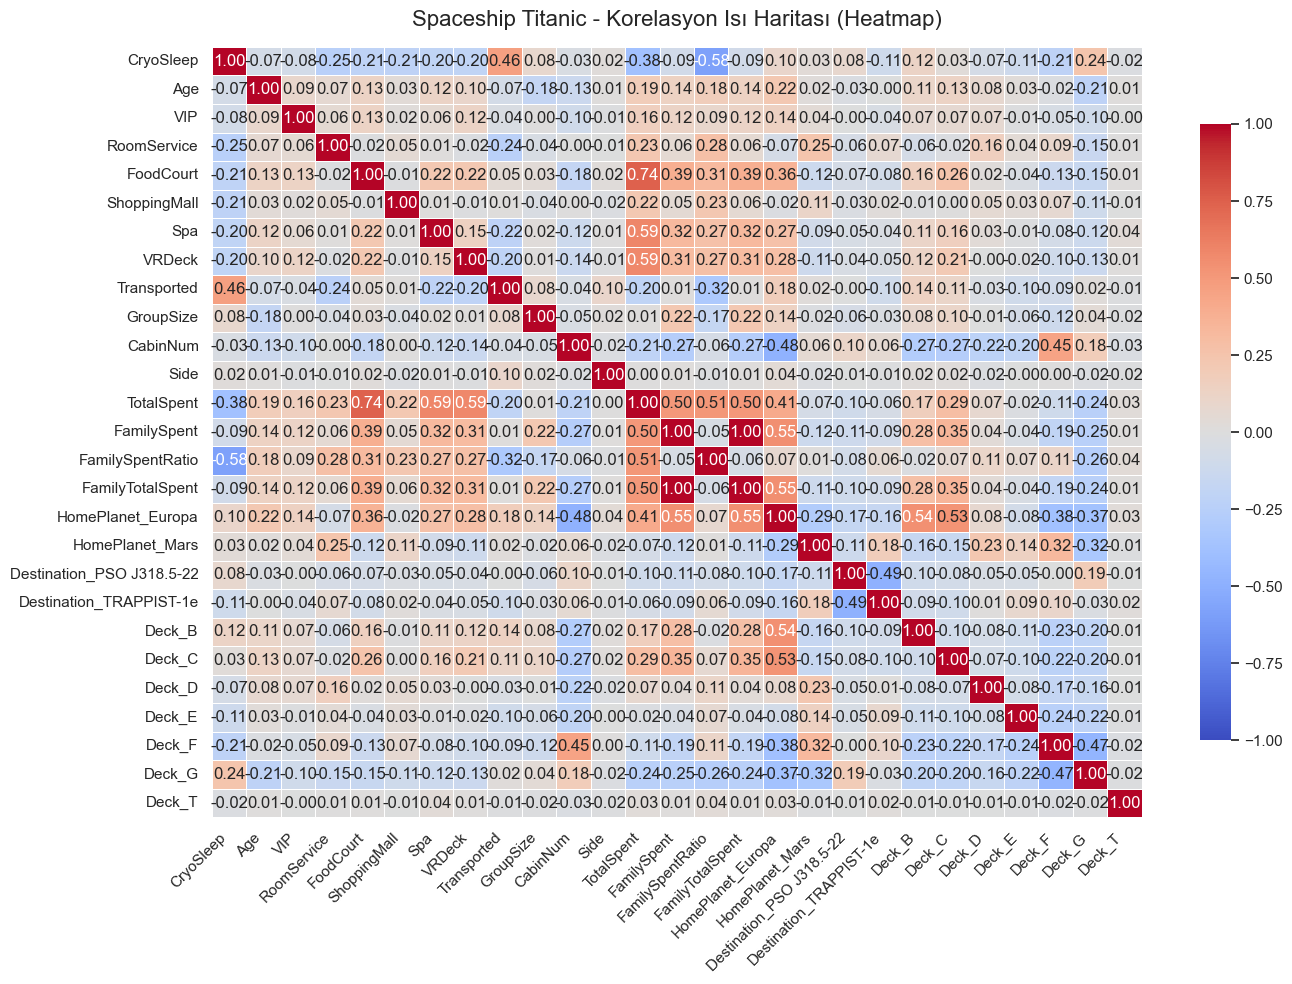

In [112]:
# Kategorik veriler (isim, gezegen vb.) korelasyona dahil edilemez.
numeric_cols = df_train.select_dtypes(include=['int64', 'float64', 'bool']).columns

# 2. Korelasyon matrisini hesaplama
corr_matrix = df_train[numeric_cols].corr()

# 3. Görselin boyutunu ayarlama (Sütun sayın arttığı için büyük tutmakta fayda var)
plt.figure(figsize=(14, 10))

# 4. Isı Haritasını (Heatmap) çizdirme
sns.heatmap(corr_matrix, 
            annot=True,          # Kutucukların içine değerleri yazdırır
            cmap='coolwarm',     # Mavi (Negatif) - Kırmızı (Pozitif) renk paleti
            fmt=".2f",           # Sayıları virgülden sonra 2 basamak gösterecek şekilde ayarlar
            linewidths=0.5,      # Kutucuklar arasına ince çizgiler çeker
            vmin=-1, vmax=1,     # Renk skalasını kesin olarak -1 ile 1 arasında sabitler
            cbar_kws={"shrink": .8}) # Yandaki renk çubuğunu biraz küçültür (görsel olarak daha şık durur)

# 5. Başlık ekleme ve gösterme
plt.title('Spaceship Titanic - Korelasyon Isı Haritası (Heatmap)', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right') # X eksenindeki yazıları daha okunaklı olması için eğer
plt.tight_layout()
plt.show()

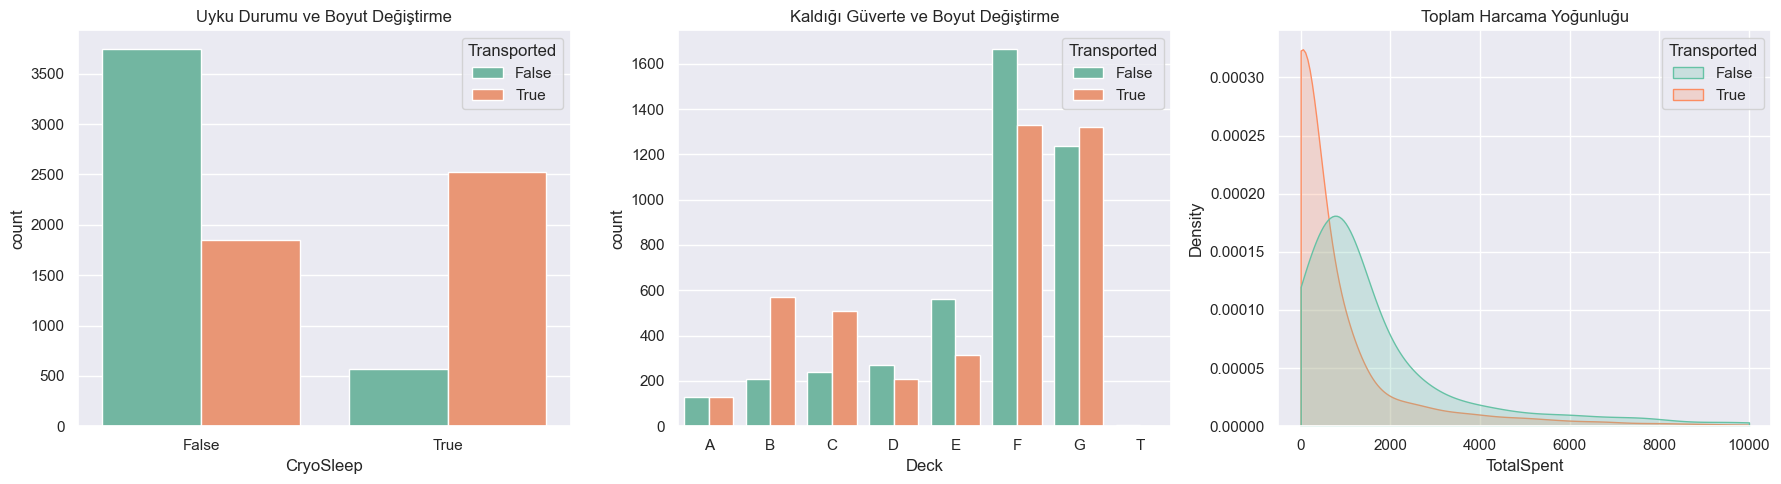

In [113]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_train_clean, x='CryoSleep', hue='Transported', ax=axes[0], palette='Set2')
axes[0].set_title('Uyku Durumu ve Boyut Değiştirme')

deck_order = sorted(df_train_clean['Deck'].dropna().unique())
sns.countplot(data=df_train_clean, x='Deck', hue='Transported', order=deck_order, ax=axes[1], palette='Set2')
axes[1].set_title('Kaldığı Güverte ve Boyut Değiştirme')

sns.kdeplot(data=df_train_clean, x='TotalSpent', hue='Transported', fill=True, ax=axes[2], palette='Set2', clip=(0, 10000))
axes[2].set_title('Toplam Harcama Yoğunluğu')

plt.tight_layout()
plt.show()

# BÖLÜM 6: MODELLEME VE ENSEMBLE (V1)
Modellerimizi kuruyor ve Stacking Ensemble ile %80.5'lik skorumuzu üretiyoruz.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

X = df_train.drop(columns=['Transported'], errors='ignore').copy()
y = df_train['Transported'].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_model = CatBoostClassifier(verbose=0, random_state=42)
lgb_model = LGBMClassifier(random_state=42, n_estimators=100, verbose=-1)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

print('\n🚀 Yeni özelliklerle modeller tekrar eğitiliyor...')
results = {}
for name, model in [('CatBoost', cat_model), ('LightGBM', lgb_model), ('XGBoost', xgb_model)]:
    t = time.time()
    sc = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = sc
    print(f'✅ {name}: %{sc.mean()*100:.2f} (±{sc.std()*100:.2f}) | {time.time()-t:.1f}s')

print('\n🏗️ Stacking Ensemble kuruluyor...')
print('(Modellerin tahminlerini üzerine bir Logistic Regression oturtuyor)')
stack_model = StackingClassifier(
    estimators=[('cat', cat_model), ('lgb', lgb_model), ('xgb', xgb_model)],
    final_estimator=LogisticRegression(), cv=5, n_jobs=-1
)
t = time.time()
sc = cross_val_score(stack_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'\n✅ Stacking: %{sc.mean()*100:.2f} (±{sc.std()*100:.2f}) | {time.time()-t:.1f}s')

import pandas as pd
print('\n' + '='*55)
print('     🏁 YENİ ÖZELLİKLER + STACKING FİNAL TABLOSU')
print('='*55)
all_results = {**{k: v.mean() for k,v in results.items()}, 'Stacking (Cat+LGB+XGB)': sc.mean()}
df_results = pd.DataFrame([(k, round(v*100,2)) for k,v in sorted(all_results.items(), key=lambda x: -x[1])], columns=['Model', 'Doğruluk (%)'])
print(df_results.to_string(index=False))

print('\n📦 Şampiyon model (Stacking) tüm veriyle eğitilip submission dosyası üretiliyor...')
stack_model.fit(X, y)
preds = stack_model.predict(df_test[X.columns]).astype(bool)
test_raw = pd.read_csv('test.csv')
sub = pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Transported': preds})
sub.to_csv('stacking_submission.csv', index=False)
print("🎉 'stacking_submission.csv' başarıyla oluşturuldu! Kaggle'a yüklemeye hazır.")
